Name: Prajakta Vishwajit Mahangare

Class:CSE(AI) SY(SEDA)

Rollno. 34  PRN NO. 12520047

Assignment no.10
Assignment on Regression technique.
Download temperature data from the link below.
https://www.kaggle.com/venky73/temperaturesof-india?select=temperatures.csv

This data consists of temperatures of INDIA averaging the temperatures of all places month wise. Temperatures values are recorded in CELSIUS
Apply Linear Regression using a suitable library function and predict the Month-wise temperature.
Assess the performance of regression models using MSE, MAE and R-Square   
metrics
Visualize a simple regression model.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
data = pd.read_csv("temperatures.csv")
print(data.head())

   YEAR    JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP    OCT  \
0  1901  22.40  24.14  29.07  31.91  33.41  33.18  31.21  30.39  30.47  29.97   
1  1902  24.93  26.58  29.77  31.78  33.73  32.91  30.92  30.73  29.80  29.12   
2  1903  23.44  25.03  27.83  31.39  32.91  33.00  31.34  29.98  29.85  29.04   
3  1904  22.50  24.73  28.21  32.02  32.64  32.07  30.36  30.09  30.04  29.20   
4  1905  22.00  22.83  26.68  30.01  33.32  33.25  31.44  30.68  30.12  30.67   

     NOV    DEC  ANNUAL  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC  
0  27.31  24.49   28.96    23.27    31.46    31.27    27.25  
1  26.31  24.04   29.22    25.75    31.76    31.09    26.49  
2  26.08  23.65   28.47    24.24    30.71    30.92    26.26  
3  26.36  23.63   28.49    23.62    30.95    30.66    26.40  
4  27.52  23.82   28.30    22.25    30.00    31.33    26.57  


Preprocessing

In [ ]:
months = ['JAN','FEB','MAR','APR','MAY','JUN',
          'JUL','AUG','SEP','OCT','NOV','DEC']

df = data[months]

df = df.melt(var_name='Month', value_name='Temperature')

month_map = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
             'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}

df['Month'] = df['Month'].map(month_map)

df.dropna(inplace=True)

Check Missing Values

In [ ]:
print(df.isnull().sum())

Month          0
Temperature    0
dtype: int64


In [ ]:
df.dropna(inplace=True)

Visualization

Scatter Plot

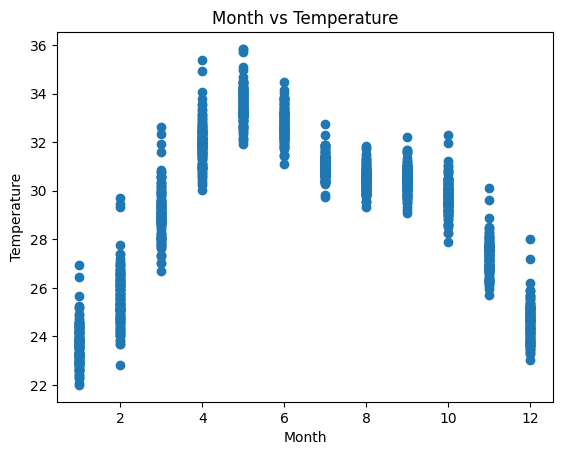

In [ ]:
plt.scatter(df['Month'], df['Temperature'])
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.title("Month vs Temperature")
plt.show()

Define X and Y

In [ ]:
X = df[['Month']]
y = df['Temperature']

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Apply Linear Regression

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Prediction

In [ ]:
y_pred = model.predict(X_test)

Metrics

In [ ]:
print("Initial Model (Month Only)")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Initial Model (Month Only)
MSE: 10.880025662559289
MAE: 2.7996033532888815
R2: -0.008412625665608742


Visualization

Scatter Plot

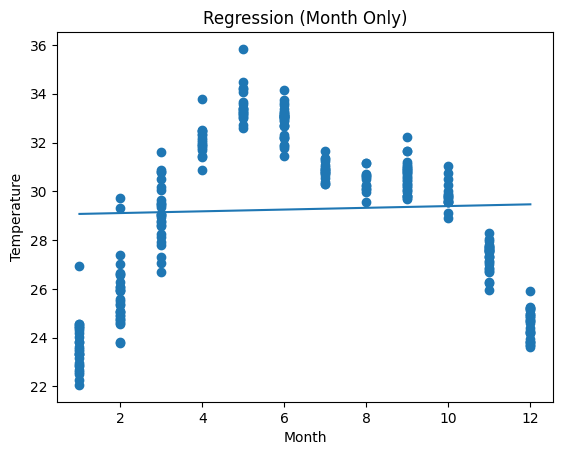

In [ ]:
sorted_idx = X_test['Month'].argsort()
X_sorted = X_test.iloc[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.scatter(X_test, y_test)
plt.plot(X_sorted, y_pred_sorted)
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.title("Regression (Month Only)")
plt.show()

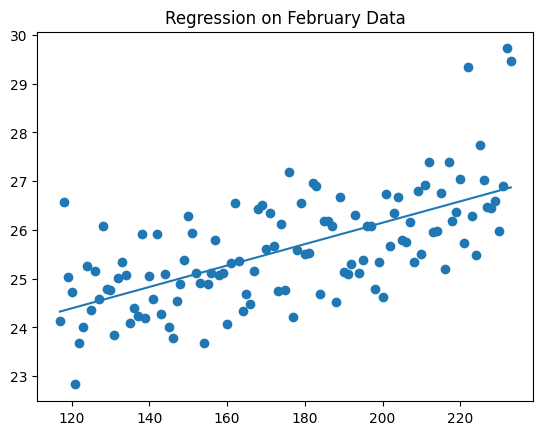

In [ ]:
feb_data = df[df['Month'] == 2]

X_feb = feb_data.index.values.reshape(-1,1)
y_feb = feb_data['Temperature']

model = LinearRegression()
model.fit(X_feb, y_feb)

y_pred_feb = model.predict(X_feb)

plt.scatter(X_feb, y_feb)
plt.plot(X_feb, y_pred_feb)
plt.title("Regression on February Data")
plt.show()

Data with year

In [ ]:
df2 = data.melt(id_vars=['YEAR'],
                value_vars=months,
                var_name='Month',
                value_name='Temperature')

df2['Month'] = df2['Month'].map(month_map)
df2.dropna(inplace=True)

In [ ]:
X2 = df2[['YEAR', 'Month']]
y2 = df2['Temperature']

In [ ]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2)

In [ ]:
model2 = LinearRegression()
model2.fit(X_train2, y_train2)

LinearRegression()

In [ ]:
y_pred2 = model2.predict(X_test2)

In [ ]:
print("Improved Model (Year + Month)")
print("MSE:", mean_squared_error(y_test2, y_pred2))
print("MAE:", mean_absolute_error(y_test2, y_pred2))
print("R2:", r2_score(y_test2, y_pred2))

Improved Model (Year + Month)
MSE: 9.592738933757683
MAE: 2.642857268177866
R2: 0.012982866381725744


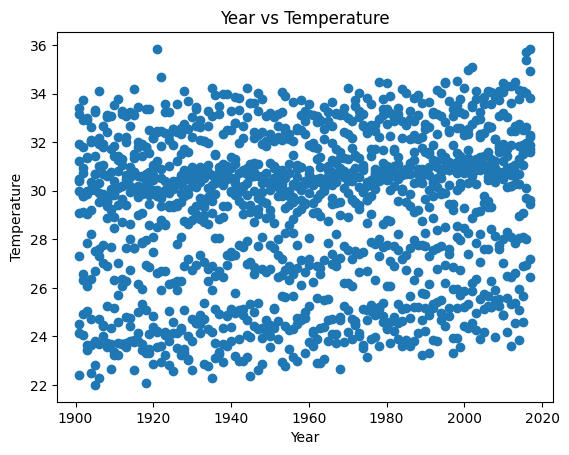

In [ ]:
plt.scatter(df2['YEAR'], df2['Temperature'])
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.title("Year vs Temperature")
plt.show()

In [ ]:
future = [[2025, m] for m in range(1,13)]
predictions = model2.predict(future)

print("Predicted Temperatures for 2025:")
for i, temp in enumerate(predictions, 1):
    print(f"Month {i}: {temp:.2f} °C")

Predicted Temperatures for 2025:
Month 1: 29.77 °C
Month 2: 29.82 °C
Month 3: 29.88 °C
Month 4: 29.93 °C
Month 5: 29.98 °C
Month 6: 30.03 °C
Month 7: 30.08 °C
Month 8: 30.13 °C
Month 9: 30.19 °C
Month 10: 30.24 °C
Month 11: 30.29 °C
Month 12: 30.34 °C


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
